# Imports and Configuration

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import time
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Configuration
dataset_path = "/kaggle/input/rare-and-endangered-medicinal-plants-in-bangladesh/Raw-Images"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 16
EPOCHS = 50

# Class names
class_names = [
    'Kalochitra', 'Anantamu', 'Apang', 'Syspan', 'Appishikha', 
    'Kalamegh', 'Kalothutura', 'Gshnru', 'Chapalish', 'Beta',
    'Punarnava', 'Bamonhati', 'Basok', 'Ramtulsi', 'Shotomuli', 'Sarpagandha'
]

print("Libraries imported and configuration set!")

2025-11-30 15:25:25.138981: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764516325.159625     239 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764516325.165967     239 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Libraries imported and configuration set!


# CBAM Attention Module

In [2]:
# CBAM Attention Module
class CBAM(keras.layers.Layer):
    def __init__(self, reduction_ratio=16, **kwargs):
        super(CBAM, self).__init__(**kwargs)
        self.reduction_ratio = reduction_ratio

    def build(self, input_shape):
        self.channel = input_shape[-1]
        
        # Channel Attention
        self.channel_avg_pool = layers.GlobalAveragePooling2D()
        self.channel_max_pool = layers.GlobalMaxPooling2D()
        self.channel_dense1 = layers.Dense(self.channel // self.reduction_ratio, activation='relu')
        self.channel_dense2 = layers.Dense(self.channel)
        
        # Spatial Attention
        self.spatial_conv = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')
        
        super(CBAM, self).build(input_shape)

    def call(self, inputs):
        # Channel Attention
        avg_pool = self.channel_avg_pool(inputs)
        max_pool = self.channel_max_pool(inputs)
        
        avg_out = self.channel_dense2(self.channel_dense1(avg_pool))
        max_out = self.channel_dense2(self.channel_dense1(max_pool))
        
        channel_attention = tf.sigmoid(avg_out + max_out)
        channel_attention = tf.reshape(channel_attention, [-1, 1, 1, self.channel])
        
        # Apply channel attention
        x = inputs * channel_attention
        
        # Spatial Attention
        avg_pool_spatial = tf.reduce_mean(x, axis=3, keepdims=True)
        max_pool_spatial = tf.reduce_max(x, axis=3, keepdims=True)
        spatial_attention = tf.concat([avg_pool_spatial, max_pool_spatial], axis=3)
        spatial_attention = self.spatial_conv(spatial_attention)
        
        # Apply spatial attention
        output = x * spatial_attention
        
        return output

    def get_config(self):
        config = super(CBAM, self).get_config()
        config.update({'reduction_ratio': self.reduction_ratio})
        return config

print("CBAM Attention Module defined!")

CBAM Attention Module defined!


# Model Architecture

In [3]:
def build_attention_cnn_model():
    inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    
    # Initial Convolution Block
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Second Convolution Block with CBAM
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = CBAM(reduction_ratio=16)(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Third Convolution Block
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = CBAM(reduction_ratio=16)(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Fourth Convolution Block
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = CBAM(reduction_ratio=16)(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Global Pooling and Fully Connected Layers
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    
    # Output Layer
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

# Create and display model
model = build_attention_cnn_model()
print("Attention-Enhanced CNN Model built!")
model.summary()

I0000 00:00:1764516330.664891     239 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764516330.665484     239 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Attention-Enhanced CNN Model built!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cbam (CBAM)                     │ (None, 112, 112, 64)   │           679 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cbam_1 (CBAM)                   │ (None, 56, 56, 128)    │         2,283 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cbam_2 (CBAM)                   │ (None, 28, 28, 256)    │         8,563 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,410,133 (5.38 MB)

 Trainable params: 1,407,381 (5.37 MB)

 Non-trainable params: 2,752 (10.75 KB)

# Data Generators

In [4]:
def create_data_generators():
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True,
        zoom_range=0.2,
        brightness_range=[0.8, 1.2],
        validation_split=0.2
    )
    
    test_datagen = ImageDataGenerator(rescale=1./255)
    
    train_generator = train_datagen.flow_from_directory(
        dataset_path,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='training',
        shuffle=True
    )
    
    validation_generator = train_datagen.flow_from_directory(
        dataset_path,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='validation',
        shuffle=False
    )
    
    return train_generator, validation_generator

print("Creating data generators...")
train_gen, val_gen = create_data_generators()
print(f"Training samples: {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")
print(f"Class indices: {train_gen.class_indices}")

Creating data generators...
Found 2804 images belonging to 16 classes.
Found 690 images belonging to 16 classes.
Training samples: 2804
Validation samples: 690
Class indices: {'type_1': 0, 'type_10': 1, 'type_11': 2, 'type_12': 3, 'type_13': 4, 'type_14': 5, 'type_15': 6, 'type_16': 7, 'type_2': 8, 'type_3': 9, 'type_4': 10, 'type_5': 11, 'type_6': 12, 'type_7': 13, 'type_8': 14, 'type_9': 15}


# Compile and Train Model

In [5]:
# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-7
    )
]

# Train model
print("Starting training...")
start_time = time.time()

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time
print(f"Training completed in {training_time:.2f} seconds")

Starting training...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1764516340.928263     291 service.cc:148] XLA service 0x7bdaec130530 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764516340.929318     291 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764516340.929343     291 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764516342.104043     291 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/88 ━━━━━━━━━━━━━━━━━━━━ 32:38 23s/step - accuracy: 0.0938 - loss: 2.9517

I0000 00:00:1764516355.685031     291 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


88/88 ━━━━━━━━━━━━━━━━━━━━ 103s 920ms/step - accuracy: 0.1531 - loss: 2.6202 - val_accuracy: 0.0841 - val_loss: 2.8126 - learning_rate: 0.0010
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 48s 540ms/step - accuracy: 0.4034 - loss: 1.7443 - val_accuracy: 0.0841 - val_loss: 2.8633 - learning_rate: 0.0010
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 47s 531ms/step - accuracy: 0.5291 - loss: 1.3378 - val_accuracy: 0.0841 - val_loss: 3.1340 - learning_rate: 0.0010
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 46s 526ms/step - accuracy: 0.6087 - loss: 1.1104 - val_accuracy: 0.0507 - val_loss: 2.9288 - learning_rate: 0.0010
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 47s 530ms/step - accuracy: 0.7031 - loss: 0.8820 - val_accuracy: 0.1000 - val_loss: 3.5556 - learning_rate: 0.0010
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 47s 529ms/step - accuracy: 0.7262 - loss: 0.8033 - val_accuracy: 0.2391 - val_loss: 2.5757 - learning_rate: 0.0010
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 47s 533ms/step - accuracy: 0.7679 - loss: 0.6830 - val

# Model Evaluation

In [6]:
def evaluate_model(model, val_gen, training_time):
    print("Evaluating model...")
    
    # Predict on validation set
    start_time = time.time()
    y_pred = model.predict(val_gen)
    testing_time = time.time() - start_time
    
    y_true = val_gen.classes
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_pred_proba = y_pred
    
    # Calculate metrics
    val_loss, val_accuracy = model.evaluate(val_gen, verbose=0)
    
    # Classification report
    class_report = classification_report(y_true, y_pred_classes, 
                                       target_names=class_names, output_dict=True)
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred_classes)
    
    # ROC Curve and AUC
    y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
    
    # Calculate ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(NUM_CLASSES):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Calculate macro-average AUC
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(NUM_CLASSES)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(NUM_CLASSES):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= NUM_CLASSES
    
    macro_auc = auc(all_fpr, mean_tpr)
    
    return {
        'val_accuracy': val_accuracy,
        'val_loss': val_loss,
        'classification_report': class_report,
        'confusion_matrix': cm,
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': roc_auc,
        'macro_auc': macro_auc,
        'training_time': training_time,
        'testing_time': testing_time,
        'y_true': y_true,
        'y_pred_classes': y_pred_classes,
        'y_pred_proba': y_pred_proba
    }

# Evaluate the model
results = evaluate_model(model, val_gen, training_time)

Evaluating model...
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 477ms/step


# Visualization Functions

Generating visualizations...


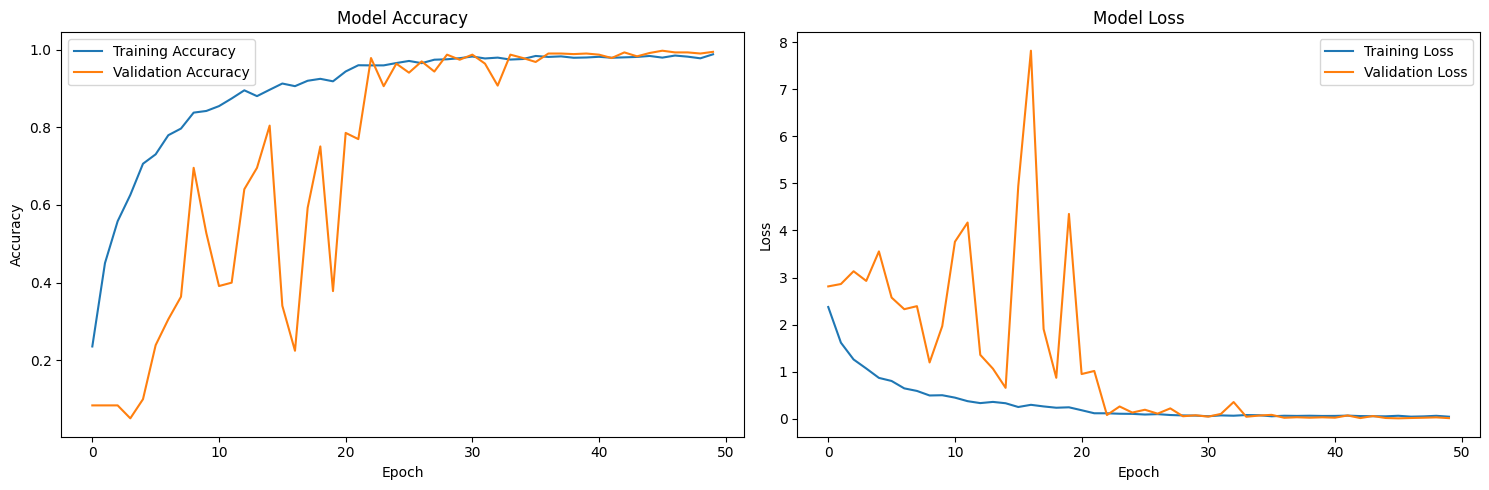

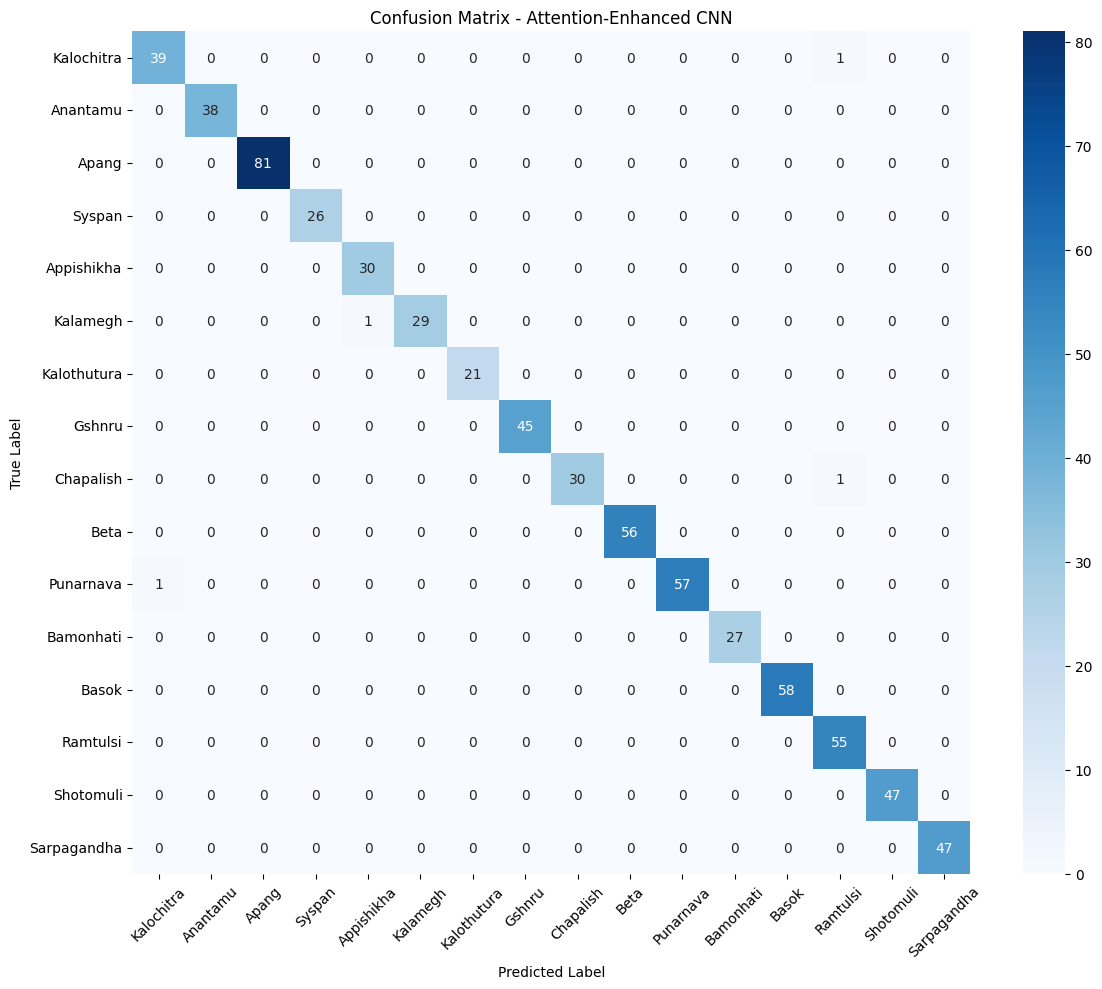

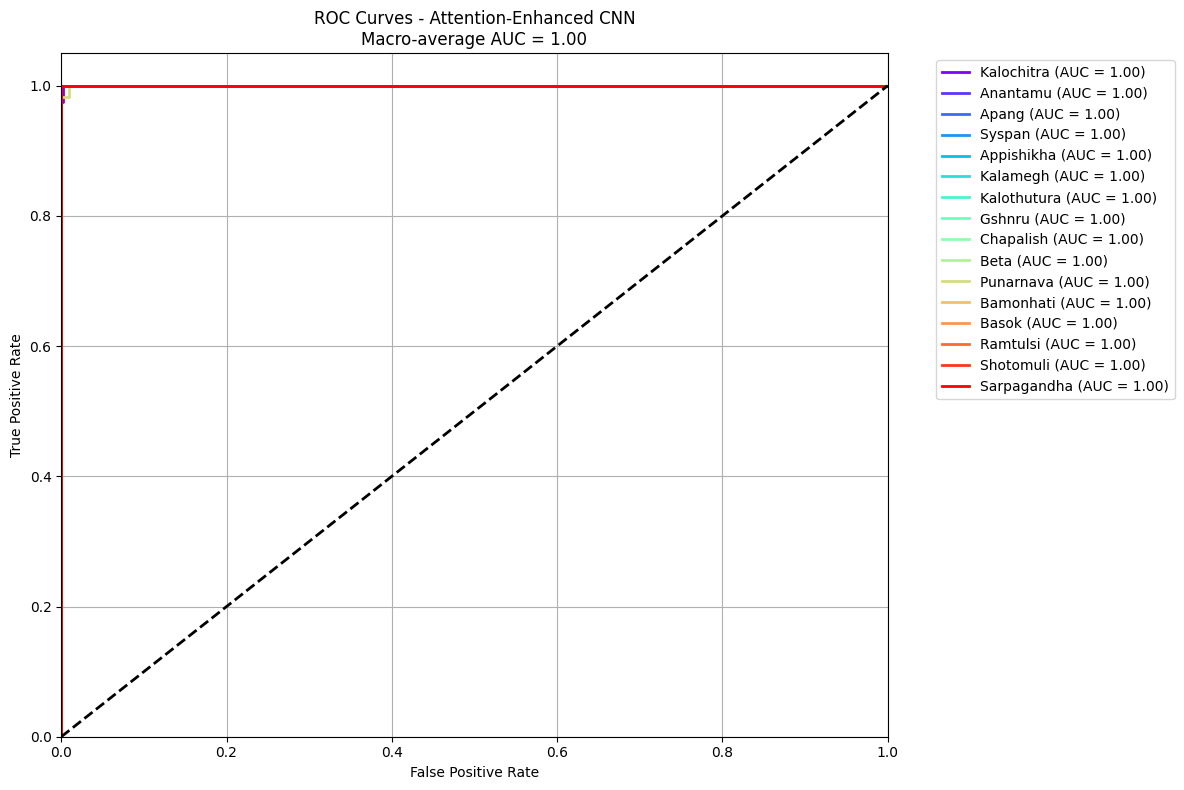

In [7]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot training & validation accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    
    # Plot training & validation loss
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - Attention-Enhanced CNN')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def plot_roc_curve(fpr, tpr, roc_auc, macro_auc, class_names):
    plt.figure(figsize=(12, 8))
    
    colors = plt.cm.rainbow(np.linspace(0, 1, NUM_CLASSES))
    for i, color in zip(range(NUM_CLASSES), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                label='{0} (AUC = {1:0.2f})'.format(class_names[i], roc_auc[i]))
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves - Attention-Enhanced CNN\nMacro-average AUC = {0:0.2f}'.format(macro_auc))
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Generate visualizations
print("Generating visualizations...")
plot_training_history(history)
plot_confusion_matrix(results['confusion_matrix'], class_names)
plot_roc_curve(results['fpr'], results['tpr'], results['roc_auc'], 
              results['macro_auc'], class_names)

# Print Detailed Result

In [8]:
def print_detailed_metrics(results, class_names):
    print("\n" + "="*80)
    print("ATTENTION-ENHANCED CNN MODEL - COMPREHENSIVE EVALUATION")
    print("="*80)
    
    print(f"\nOverall Accuracy: {results['val_accuracy']:.4f}")
    print(f"Macro-average AUC: {results['macro_auc']:.4f}")
    print(f"Training Time: {results['training_time']:.2f} seconds")
    print(f"Testing Time: {results['testing_time']:.2f} seconds")
    
    print(f"\nClass-wise Accuracy:")
    for i, class_name in enumerate(class_names):
        accuracy = results['classification_report'][class_name]['precision']
        print(f"  {class_name}: {accuracy:.4f}")
    
    print(f"\nClass-wise AUC:")
    for i, class_name in enumerate(class_names):
        print(f"  {class_name}: {results['roc_auc'][i]:.4f}")
    
    # Calculate and print macro averages
    macro_precision = results['classification_report']['macro avg']['precision']
    macro_recall = results['classification_report']['macro avg']['recall']
    macro_f1 = results['classification_report']['macro avg']['f1-score']
    
    print(f"\nMacro-average Precision: {macro_precision:.4f}")
    print(f"Macro-average Recall: {macro_recall:.4f}")
    print(f"Macro-average F1-Score: {macro_f1:.4f}")

# Print detailed results
print_detailed_metrics(results, class_names)

# Save the model
model.save('attention_enhanced_cnn_model.h5')
print("\nModel saved as 'attention_enhanced_cnn_model.h5'")


ATTENTION-ENHANCED CNN MODEL - COMPREHENSIVE EVALUATION

Overall Accuracy: 0.9884
Macro-average AUC: 1.0000
Training Time: 2388.49 seconds
Testing Time: 13.09 seconds

Class-wise Accuracy:
  Kalochitra: 0.9750
  Anantamu: 1.0000
  Apang: 1.0000
  Syspan: 1.0000
  Appishikha: 0.9677
  Kalamegh: 1.0000
  Kalothutura: 1.0000
  Gshnru: 1.0000
  Chapalish: 1.0000
  Beta: 1.0000
  Punarnava: 1.0000
  Bamonhati: 1.0000
  Basok: 1.0000
  Ramtulsi: 0.9649
  Shotomuli: 1.0000
  Sarpagandha: 1.0000

Class-wise AUC:
  Kalochitra: 1.0000
  Anantamu: 1.0000
  Apang: 1.0000
  Syspan: 1.0000
  Appishikha: 1.0000
  Kalamegh: 1.0000
  Kalothutura: 1.0000
  Gshnru: 1.0000
  Chapalish: 1.0000
  Beta: 1.0000
  Punarnava: 0.9998
  Bamonhati: 1.0000
  Basok: 1.0000
  Ramtulsi: 1.0000
  Shotomuli: 1.0000
  Sarpagandha: 1.0000

Macro-average Precision: 0.9942
Macro-average Recall: 0.9933
Macro-average F1-Score: 0.9937

Model saved as 'attention_enhanced_cnn_model.h5'


# Detailed Metrics Report

In [11]:
print("\n" + "="*80)
print("Result SUMMARY")
print("="*80)

print(f"\nAttention-Enhanced CNN Model Performance:")
print(f"  • Overall Accuracy: {results['val_accuracy']:.4f}")
print(f"  • Macro-average AUC: {results['macro_auc']:.4f}")
print(f"  • Training Time: {results['training_time']:.2f} seconds")
print(f"  • Testing Time: {results['testing_time']:.2f} seconds")
print(f"  • Number of Parameters: {model.count_params():,}")

print(f"\nKey Features:")
print(f"  • CBAM Attention Modules: 3 layers")
print(f"  • Batch Normalization: Applied after each conv layer")
print(f"  • Dropout: 0.5 in dense layers for regularization")
print(f"  • Data Augmentation: Rotation, flipping, zooming, brightness adjustment")



Result SUMMARY

Attention-Enhanced CNN Model Performance:
  • Overall Accuracy: 0.9884
  • Macro-average AUC: 1.0000
  • Training Time: 2388.49 seconds
  • Testing Time: 13.09 seconds
  • Number of Parameters: 1,410,133

Key Features:
  • CBAM Attention Modules: 3 layers
  • Batch Normalization: Applied after each conv layer
  • Dropout: 0.5 in dense layers for regularization
  • Data Augmentation: Rotation, flipping, zooming, brightness adjustment


# Save Final Model and Results

In [12]:
# Save the final model
model.save('attention_enhanced_cnn_final.h5')
print("\nFinal model saved as 'attention_enhanced_cnn_final.h5'")

# Save results for comparison with other tasks
import pickle
with open('attention_model_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print("Results saved as 'attention_model_results.pkl'")
print(f"Final Validation Accuracy: {results['val_accuracy']:.4f}")
print(f"Final Macro AUC: {results['macro_auc']:.4f}")
print(f"Training completed in {results['training_time']:.2f} seconds")


Final model saved as 'attention_enhanced_cnn_final.h5'
Results saved as 'attention_model_results.pkl'
Final Validation Accuracy: 0.9884
Final Macro AUC: 1.0000
Training completed in 2388.49 seconds
